In [3]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import numpy as np

from scipy import stats
from scipy.stats import skew, kurtosis

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [4]:
# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None) # 모든 컬럼이 다 보인다.
pd.set_option('display.max_rows', 100) # 행 출력 개수 제한

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [5]:
#데이터 로드

df_customers = pd.read_csv("../data/olist_customers_dataset.csv")
df_geolocation = pd.read_csv("../data/olist_geolocation_dataset.csv")
df_order_items = pd.read_csv("../data/olist_order_items_dataset.csv")
df_order_payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
df_order_reviews = pd.read_csv("../data/olist_order_reviews_dataset.csv")
df_orders = pd.read_csv("../data/olist_orders_dataset.csv")
df_products = pd.read_csv("../data/olist_products_dataset.csv")
df_sellers = pd.read_csv("../data/olist_sellers_dataset.csv")
df_translation = pd.read_csv("../data/product_category_name_translation.csv")

## 데이터 구조 및 기초 통계량 파악

In [6]:
print("\n" + "="*60)
print("Geolocation 데이터 (지리 위치 정보)")
print(f"Shape: {df_geolocation.shape}")

print("\n[Data Info]")
print("="*60)
df_geolocation.info()
print("="*60)

print("\n[Describe]")
df_geolocation.describe(include='all')



Geolocation 데이터 (지리 위치 정보)
Shape: (1000163, 5)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  str    
 4   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(2)
memory usage: 38.2 MB

[Describe]


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,NaN,NaN,8011,27
top,NaN,NaN,NaN,sao paulo,SP
freq,NaN,NaN,NaN,135800,404268
mean,3.657417e+04,-2.117615e+01,-4.639054e+01,NaN,NaN
std,3.054934e+04,5.715866e+00,4.269748e+00,NaN,NaN
min,1.001000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,1.107500e+04,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,2.653000e+04,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,6.350400e+04,-1.997962e+01,-4.376771e+01,NaN,NaN


In [7]:
print("\n" + "="*60)
print("Order_Items 데이터 (주문 항목 정보)")
print(f"Shape: {df_order_items.shape}")

print("\n[Data Info]")
print("="*60)
df_order_items.info()
print("="*60)

print("\n[Describe]")
df_order_items.describe(include='all')


Order_Items 데이터 (주문 항목 정보)
Shape: (112650, 7)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB

[Describe]


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2018-03-01 02:50:48,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [8]:
print("\n" + "="*60)
print("Products 데이터 (상품 정보)")
print(f"Shape: {df_products.shape}")

print("\n[Data Info]")
print("="*60)
df_products.info()
print("="*60)

print("\n[Describe]")
df_products.describe(include='all')


Products 데이터 (상품 정보)
Shape: (32951, 9)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
memory usage: 2.3 MB

[Describe]


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [9]:
print("\n" + "="*60)
print("Sellers 데이터 (판매자 정보)")
print(f"Shape: {df_sellers.shape}")

print("\n[Data Info]")
df_sellers.shape
print("="*60)
df_sellers.info()
print("="*60)

print("\n[Describe]")
df_sellers.describe(include='all')


Sellers 데이터 (판매자 정보)
Shape: (3095, 4)

[Data Info]
<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB

[Describe]


,seller_id,seller_zip_code_prefix,seller_city,seller_state
count,3095,3095.000000,3095,3095
unique,3095,NaN,611,23
top,3442f8959a84dea7ee197c632cb2df15,NaN,sao paulo,SP
freq,1,NaN,694,1849
mean,NaN,32291.059451,NaN,NaN
std,NaN,32713.453830,NaN,NaN
min,NaN,1001.000000,NaN,NaN
25%,NaN,7093.500000,NaN,NaN
50%,NaN,14940.000000,NaN,NaN
75%,NaN,64552.500000,NaN,NaN


### 샘플 데이터 확인

In [10]:
tables = {
    #"olist_customers_dataset": df_customers,
    ##"olist_geolocation_dataset": df_geolocation,
    "olist_order_items_dataset": df_order_items,
    #"olist_order_payments_dataset": df_order_payments,
    #"olist_order_reviews_dataset": df_order_reviews,
    #"olist_orders_dataset": df_orders,
    ##"olist_products_dataset": df_products,
    "olist_sellers_dataset": df_sellers
}

In [11]:
df_geolocation['geolocation_zip_code_prefix'].value_counts().sort_index()

geolocation_zip_code_prefix
1001     26
1002     13
1003     17
1004     22
1005     25
         ..
99960     5
99965     6
99970    21
99980    26
99990     2
Name: count, Length: 19015, dtype: int64

In [12]:
for name, df in tables.items():
    print("\n" + "="*60)
    print(f"[Table Name] : {name}")
    display(df.head())


[Table Name] : olist_order_items_dataset


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



[Table Name] : olist_sellers_dataset


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


---

# 데이터 전처리
## 중복 데이터 확인

In [13]:
df_order_items

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


# 전처리 시작(Order_items / Sellers)

## 중복값 확인

In [14]:
# 전체 행 중복 확인
print("[전체 행 기준]")
print(f"Order_Items 중복: {df_order_items.duplicated().sum():,}건")
print(f"Sellers 중복: {df_sellers.duplicated().sum():,}건")

# ID 기준 중복 확인
print("="*60)
print("[ID 기준]")
print(f"Sellers(seller_id) 중복: {df_sellers.duplicated(subset='seller_id').sum():,}건")
# Order_Items의 경우 종속적 테이블이라 ID 기준 중복 진행X


[전체 행 기준]
Order_Items 중복: 0건
Sellers 중복: 0건
[ID 기준]
Sellers(seller_id) 중복: 0건


## 데이터 타입 변환

In [15]:
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


In [16]:
df_sellers.info()

<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


- 우편번호 4자리는 앞에 0을 붙이는게 낫지 않을까?
- order_items 테이블의 order_item_id는 범주형으로 가야하는건가?

In [17]:
df_order_items[df_order_items.duplicated(subset=['order_id'], keep=False).sort_values()]
# order_item_id를 범주형으로 가야하나..?

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
13,0008288aa423d2a3f00fcb17cd7d8719,1,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
14,0008288aa423d2a3f00fcb17cd7d8719,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
32,00143d0f86d6fbd9f9b38ab440ac16f5,1,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
33,00143d0f86d6fbd9f9b38ab440ac16f5,2,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
34,00143d0f86d6fbd9f9b38ab440ac16f5,3,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
...,...,...,...,...,...,...,...
112635,fff8287bbae429a99bb7e8c21d151c41,2,bee2e070c39f3dd2f6883a17a5f0da45,4e922959ae960d389249c378d1c939f5,2018-03-27 12:29:22,180.00,48.14
112640,fffb9224b6fc7c43ebb0904318b10b5f,1,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112641,fffb9224b6fc7c43ebb0904318b10b5f,2,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112642,fffb9224b6fc7c43ebb0904318b10b5f,3,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19


- shipping_limit_date : str -> datetime으로 변환

In [18]:
# df_order_items의 'shipping_limit_date' str->datetime으로 타입 변환
df_order_items['shipping_limit_date'] = pd.to_datetime(df_order_items['shipping_limit_date'])

In [19]:
df_order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  str           
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  str           
 3   seller_id            112650 non-null  str           
 4   shipping_limit_date  112650 non-null  datetime64[us]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 6.0 MB


## 컬럼명 정제
- 다 소문자로 공백없어 보이지만 혹시몰라서 진행.

In [20]:
df_order_items.columns = df_order_items.columns.str.lower().str.strip()
df_sellers.columns = df_sellers.columns.str.lower().str.strip()

print(df_order_items.columns)
print(df_sellers.columns)

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')
Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='str')


## 결측치 처리

In [21]:
print("\n" + "="*60)
print("결측치 확인")
print("="*60)

for table in tables.values():
    missing_df = pd.DataFrame({
        '결측수' : table.isnull().sum(),
        '결측비율(%)' : (table.isnull().sum() / len(table) * 100).round(2)
    })
    missing_df = missing_df[missing_df['결측수']>0].sort_values('결측수',ascending=False)

    if len(missing_df) > 0:
        print("\n[결측치 현황]")
        display(missing_df)
    else:
        print(f"\n결측치 없음")


결측치 확인

결측치 없음

결측치 없음


## 이상치 처리

In [22]:
# 1.order_item_id 개수
df_order_items['order_item_id'].value_counts().sort_index()

order_item_id
1     98666
2      9803
3      2287
4       965
5       460
6       256
7        58
8        36
9        28
10       25
11       17
12       13
13        8
14        7
15        5
16        3
17        3
18        3
19        3
20        3
21        1
Name: count, dtype: int64

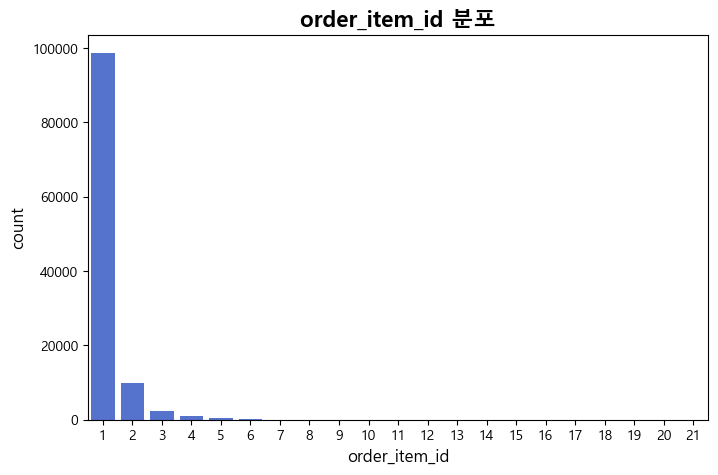

In [23]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_order_items, x='order_item_id', color='royalblue')
plt.title('order_item_id 분포', fontsize=16, fontweight='bold')
plt.xlabel('order_item_id', fontsize=12)
plt.ylabel('count', fontsize=12)

plt.show()

- 21건의 구매기록도 이상치라 판단하지 않았음.

In [24]:
# [참고] order_item_id 체크

#order_id가 동일한 녀석만 봤을 때
df_check_order_item_id = df_order_items[df_order_items.duplicated(subset=['order_id'], keep=False).sort_values()]
display(df_check_order_item_id)
print(df_check_order_item_id.shape)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
13,0008288aa423d2a3f00fcb17cd7d8719,1,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
14,0008288aa423d2a3f00fcb17cd7d8719,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
32,00143d0f86d6fbd9f9b38ab440ac16f5,1,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
33,00143d0f86d6fbd9f9b38ab440ac16f5,2,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
34,00143d0f86d6fbd9f9b38ab440ac16f5,3,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
...,...,...,...,...,...,...,...
112635,fff8287bbae429a99bb7e8c21d151c41,2,bee2e070c39f3dd2f6883a17a5f0da45,4e922959ae960d389249c378d1c939f5,2018-03-27 12:29:22,180.00,48.14
112640,fffb9224b6fc7c43ebb0904318b10b5f,1,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112641,fffb9224b6fc7c43ebb0904318b10b5f,2,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112642,fffb9224b6fc7c43ebb0904318b10b5f,3,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19


(23787, 7)


In [25]:
df_check_order_item_id = df_order_items[df_order_items.duplicated(subset=['order_id','product_id'], keep=False).sort_values()]
display(df_check_order_item_id)
print(df_check_order_item_id.shape)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
13,0008288aa423d2a3f00fcb17cd7d8719,1,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
14,0008288aa423d2a3f00fcb17cd7d8719,2,368c6c730842d78016ad823897a372db,1f50f920176fa81dab994f9023523100,2018-02-21 02:55:52,49.90,13.37
32,00143d0f86d6fbd9f9b38ab440ac16f5,1,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
33,00143d0f86d6fbd9f9b38ab440ac16f5,2,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
34,00143d0f86d6fbd9f9b38ab440ac16f5,3,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.10
...,...,...,...,...,...,...,...
112635,fff8287bbae429a99bb7e8c21d151c41,2,bee2e070c39f3dd2f6883a17a5f0da45,4e922959ae960d389249c378d1c939f5,2018-03-27 12:29:22,180.00,48.14
112640,fffb9224b6fc7c43ebb0904318b10b5f,1,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112641,fffb9224b6fc7c43ebb0904318b10b5f,2,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19
112642,fffb9224b6fc7c43ebb0904318b10b5f,3,43423cdffde7fda63d0414ed38c11a73,b1fc4f64df5a0e8b6913ab38803c57a9,2017-11-03 02:55:58,55.00,34.19


(17313, 7)


In [26]:
# 2.shipping_limit_date 데이터의 범위 확인
df_order_items['shipping_limit_date'].dt.year.value_counts().sort_index()

shipping_limit_date
2016      370
2017    49765
2018    62511
2020        4
Name: count, dtype: int64

In [27]:
# 데이터셋은 2016-2018까지의 데이터를 다룸
df2020 = df_order_items[df_order_items['shipping_limit_date'].dt.year == 2020]
df2020['shipping_limit_date'].dt.month.value_counts().sort_index()

shipping_limit_date
2    2
4    2
Name: count, dtype: int64

- olist 전자상거래 데이터셋은 2016-2018까지의 데이터를 다룸
- 2020년도의 데이터는 이상치라 판단, 개수도 4개로 극히 적어서 제거하기로 결정

In [28]:
#2020년도 데이터 제거
df_order_items = df_order_items[df_order_items['shipping_limit_date'].dt.year != 2020]
df_order_items['shipping_limit_date'].dt.year.value_counts().sort_index()

shipping_limit_date
2016      370
2017    49765
2018    62511
Name: count, dtype: int64

In [29]:
#2016이 너무 적어서, 몇월 데이터부터 있는지 확인해보자
df2016 = df_order_items[df_order_items['shipping_limit_date'].dt.year == 2016]
df2016['shipping_limit_date'].dt.month.value_counts().sort_index()

shipping_limit_date
9       4
10    365
12      1
Name: count, dtype: int64

In [30]:
# 2016년 9월 데이터 확인해보자
df2016_9 = df2016[df2016['shipping_limit_date'].dt.month == 9]
df2016_9['shipping_limit_date'].dt.day.value_counts().sort_index()

shipping_limit_date
19    4
Name: count, dtype: int64

In [31]:
# 2016년 12월 데이터 확인해보자
df2016_12 = df2016[df2016['shipping_limit_date'].dt.month == 12]
df2016_12['shipping_limit_date']

83342   2016-12-27 23:16:47
Name: shipping_limit_date, dtype: datetime64[us]

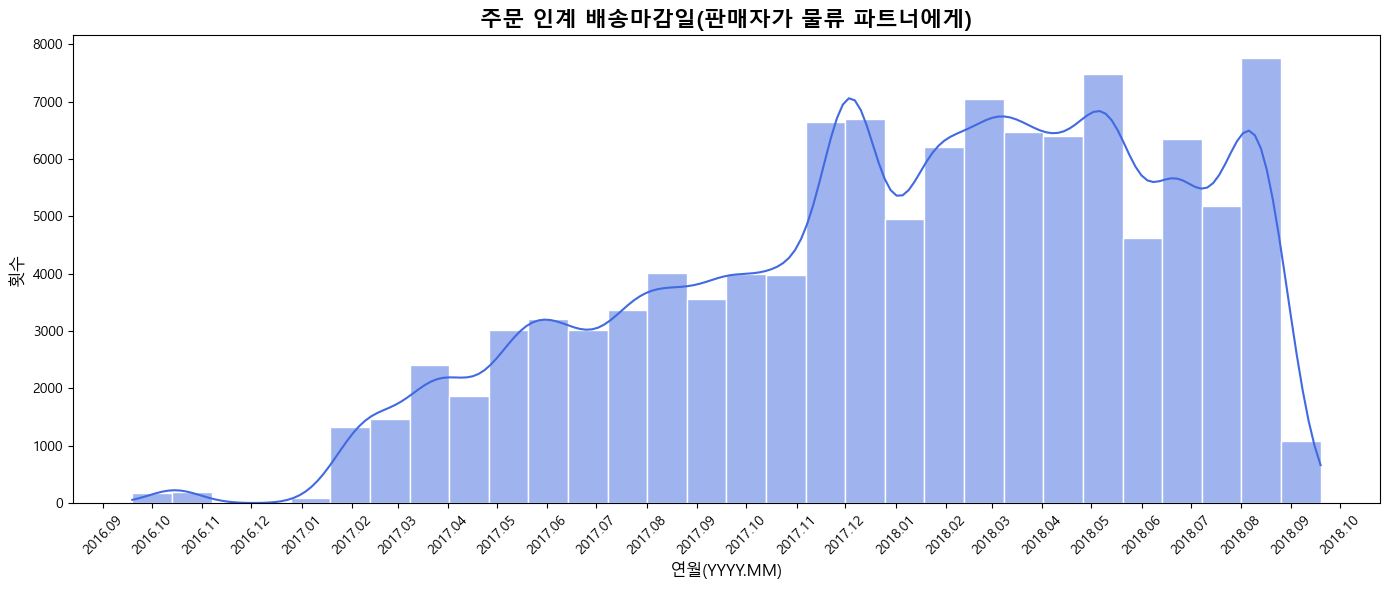

In [32]:
plt.figure(figsize=(14, 6))

# 히스토그램 + KDE 그리기
ax = sns.histplot(
    data=df_order_items, 
    x='shipping_limit_date', 
    kde=True, 
    bins=30, 
    color='royalblue',
    edgecolor='white'
)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1)) # 1개월 간격
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y.%m'))

plt.xticks(rotation=45) 
plt.title('주문 인계 배송마감일(판매자가 물류 파트너에게)', fontsize=16, fontweight='bold')
plt.xlabel('연월(YYYY.MM)', fontsize=12)
plt.ylabel('횟수', fontsize=12)

plt.tight_layout()
plt.show()

In [33]:
# 3.price 컬럼의 이상치 확인
print("[가격 기초 통계]")
print(df_order_items['price'].describe())

print("="*60)
print("\n [가격 샘플 (최소~최대)]")
print("\n최소값 10개:")
display(df_order_items.nsmallest(10, 'price'))

print("최대값 10개:")
display(df_order_items.nlargest(10,'price'))

price_skew = skew(df_order_items['price'])
price_kurt = kurtosis(df_order_items['price'])
print(f"\n왜도(Skewness): {price_skew:.3f}")
print(f"첨도(Kurtosis): {price_kurt:.3f}")

[가격 기초 통계]
count    112646.000000
mean        120.654952
std         183.637058
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64

 [가격 샘플 (최소~최대)]

최소값 10개:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
27652,3ee6513ae7ea23bdfab5b9ab60bffcb5,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-04 03:55:26,0.85,18.23
48625,6e864b3f0ec71031117ad4cf46b7f2a1,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-02 20:30:34,0.85,18.23
87081,c5bdd8ef3c0ec420232e668302179113,2,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-07 02:55:22,0.85,22.30
57297,8272b63d03f5f79c56e9e4120aec44ef,1,270516a3f41dc035aa87d220228f844c,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57298,8272b63d03f5f79c56e9e4120aec44ef,2,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57299,8272b63d03f5f79c56e9e4120aec44ef,3,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57300,8272b63d03f5f79c56e9e4120aec44ef,4,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57301,8272b63d03f5f79c56e9e4120aec44ef,5,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57302,8272b63d03f5f79c56e9e4120aec44ef,6,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
57303,8272b63d03f5f79c56e9e4120aec44ef,7,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89


최대값 10개:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.00,194.31
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.00,193.21
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.00,227.66
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.00,151.34
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.00,74.34
62086,8dbc85d1447242f3b127dda390d56e19,1,259037a6a41845e455183f89c5035f18,c72de06d72748d1a0dfb2125be43ba63,2018-06-28 12:36:36,4590.00,91.78
29193,426a9742b533fc6fed17d1fd6d143d7e,1,a1beef8f3992dbd4cd8726796aa69c53,512d298ac2a96d1931b6bd30aa21f61d,2018-08-16 14:24:28,4399.87,113.45
45843,68101694e5c5dc7330c91e1bbc36214f,1,6cdf8fc1d741c76586d8b6b15e9eef30,ed4acab38528488b65a9a9c603ff024a,2018-04-05 08:27:27,4099.99,75.27
78310,b239ca7cd485940b31882363b52e6674,1,dd113cb02b2af9c8e5787e8f1f0722f6,821fb029fc6e495ca4f08a35d51e53a5,2018-08-02 08:15:14,4059.00,104.51
59137,86c4eab1571921a6a6e248ed312f5a5a,1,6902c1962dd19d540807d0ab8fade5c6,fa1c13f2614d7b5c4749cbc52fecda94,2017-03-23 20:08:04,3999.90,17.01



왜도(Skewness): 7.923
첨도(Kurtosis): 120.819


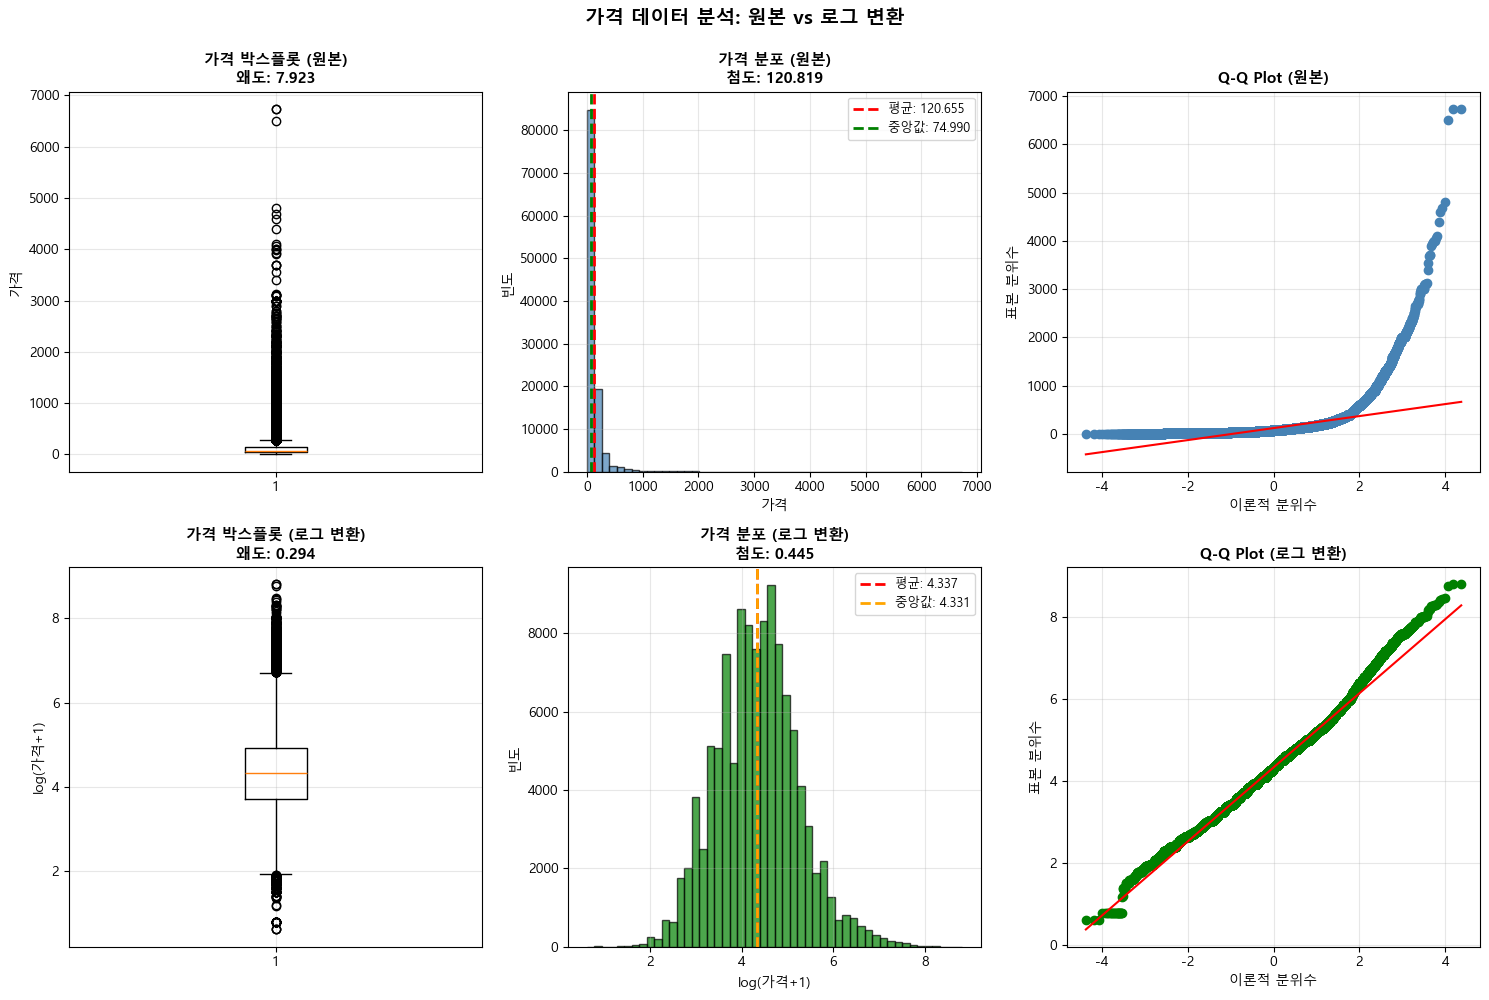

In [34]:
# 시각화 - 원본 vs 로그 변환 비교
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 로그 변환
price_log = np.log1p(df_order_items['price'])  # log(price + 1)

# 로그 변환 후 왜도와 첨도
price_log_skew = skew(price_log)
price_log_kurt = kurtosis(price_log)

# ============================================================================
# 첫 번째 행: 원본 데이터
# ============================================================================

# 1. 박스플롯 (원본)
axes[0, 0].boxplot(df_order_items['price'])
axes[0, 0].set_title(f'가격 박스플롯 (원본)\n왜도: {price_skew:.3f}', 
                     fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('가격')
axes[0, 0].grid(True, alpha=0.3)

# 2. 히스토그램 (원본)
axes[0, 1].hist(df_order_items['price'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].axvline(df_order_items['price'].mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'평균: {df_order_items["price"].mean():.3f}')
axes[0, 1].axvline(df_order_items['price'].median(), color='green', linestyle='--',
                    linewidth=2, label=f'중앙값: {df_order_items["price"].median():.3f}')
axes[0, 1].set_title(f'가격 분포 (원본)\n첨도: {price_kurt:.3f}', 
                     fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('가격')
axes[0, 1].set_ylabel('빈도')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot (원본)
stats.probplot(df_order_items['price'], dist="norm", plot=axes[0, 2])
axes[0, 2].get_lines()[0].set_markerfacecolor('steelblue')  # 점 색상 통일
axes[0, 2].get_lines()[0].set_markeredgecolor('steelblue')
axes[0, 2].set_title('Q-Q Plot (원본)', fontsize=11, fontweight='bold')
axes[0, 2].set_xlabel('이론적 분위수')
axes[0, 2].set_ylabel('표본 분위수')
axes[0, 2].grid(True, alpha=0.3)

# ============================================================================
# 두 번째 행: 로그 변환 데이터
# ============================================================================

# 1. 박스플롯 (로그)
axes[1, 0].boxplot(price_log)
axes[1, 0].set_title(f'가격 박스플롯 (로그 변환)\n왜도: {price_log_skew:.3f}', 
                     fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('log(가격+1)')
axes[1, 0].grid(True, alpha=0.3)

# 2. 히스토그램 (로그)
axes[1, 1].hist(price_log, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].axvline(price_log.mean(), color='red', linestyle='--',
                    linewidth=2, label=f'평균: {price_log.mean():.3f}')
axes[1, 1].axvline(price_log.median(), color='orange', linestyle='--',
                    linewidth=2, label=f'중앙값: {price_log.median():.3f}')
axes[1, 1].set_title(f'가격 분포 (로그 변환)\n첨도: {price_log_kurt:.3f}', 
                     fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('log(가격+1)')
axes[1, 1].set_ylabel('빈도')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

# 3. Q-Q plot (로그)
stats.probplot(price_log, dist="norm", plot=axes[1, 2])
axes[1, 2].get_lines()[0].set_markerfacecolor('green')  # 점 색상 통일
axes[1, 2].get_lines()[0].set_markeredgecolor('green')
axes[1, 2].set_title('Q-Q Plot (로그 변환)', fontsize=11, fontweight='bold')
axes[1, 2].set_xlabel('이론적 분위수')
axes[1, 2].set_ylabel('표본 분위수')
axes[1, 2].grid(True, alpha=0.3)

# 전체 제목
fig.suptitle('가격 데이터 분석: 원본 vs 로그 변환', fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()


In [35]:
# 4. freight_value 이상치 확인
print("[품목별 운송비 기초 통계]")
print(df_order_items['freight_value'].describe())

print("="*60)
print("\n [운송비 샘플 (최소~최대)]")
print("\n최소값 10개:")
display(df_order_items.nsmallest(10, 'freight_value'))

print("최대값 10개:")
display(df_order_items.nlargest(10,'freight_value'))


price_skew = skew(df_order_items['freight_value'])
price_kurt = kurtosis(df_order_items['freight_value'])
print(f"\n왜도(Skewness): {price_skew:.3f}")
print(f"첨도(Kurtosis): {price_kurt:.3f}")

[품목별 운송비 기초 통계]
count    112646.000000
mean         19.989678
std          15.805705
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

 [운송비 샘플 (최소~최대)]

최소값 10개:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
114,00404fa7a687c8c44ca69d42695aae73,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-15 04:31:26,99.9,0.0
258,00a870c6c06346e85335524935c600c0,1,aca2eb7d00ea1a7b8ebd4e68314663af,955fee9216a65b617aa5c0531780ce60,2018-05-14 00:14:29,69.9,0.0
483,011c899816ea29773525bd3322dbb6aa,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-07 05:30:45,99.9,0.0
508,012b3f6ab7776a8ab3443a4ad7bef2e6,1,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-05-09 21:30:50,53.9,0.0
509,012b3f6ab7776a8ab3443a4ad7bef2e6,2,422879e10f46682990de24d770e7f83d,1f50f920176fa81dab994f9023523100,2018-05-09 21:30:50,53.9,0.0
1784,04105b54650921ca3246f52e6f175f46,1,aca2eb7d00ea1a7b8ebd4e68314663af,955fee9216a65b617aa5c0531780ce60,2018-04-27 09:31:35,69.9,0.0
2232,0517a3e68dac3308995edca2144db36e,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-03 19:11:40,99.9,0.0
2714,061ba2e2d7544790b6ed6b5b4dd9278c,1,53b36df67ebb7c41585e8d54d6772e08,7d13fca15225358621be4086e1eb0964,2018-05-09 23:10:46,110.0,0.0
3224,07441f525824bc6b31d4dc19c5d49fc9,1,53b36df67ebb7c41585e8d54d6772e08,4869f7a5dfa277a7dca6462dcf3b52b2,2018-04-26 13:31:30,106.9,0.0
3378,079f16689c29acb6cab92978e6af2137,1,aca2eb7d00ea1a7b8ebd4e68314663af,955fee9216a65b617aa5c0531780ce60,2018-05-11 18:15:13,69.9,0.0


최대값 10개:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
73486,a77e1550db865202c56b19ddc6dc4d53,1,ec31d2a17b299511e7c8627be9337b9b,257e61d3251fb5efb9daadddbc2cf7ca,2018-04-25 06:55:13,979.00,409.68
3303,076d1555fb53a89b0ef4d529e527a0f6,1,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,2018-08-07 04:35:22,2338.08,375.28
28044,3fde74c28a3d5d618c00f26d51baafa0,1,a3cd9517ebf5a50dca25acce54f3b171,6fa9202c10491e472dffd59a3e82b2a3,2018-08-22 03:15:09,2338.08,375.28
69797,9f49bd16053df810384e793386312674,1,256a9c364b75753b97bee410c9491ad8,5c030029b5916fed0986310385ec9009,2018-08-02 03:44:28,1149.00,339.59
16731,264a7e199467906c0727394df82d1a6a,1,97c948ebc8c04b26b7bbb095d4228f2a,17f51e7198701186712e53a39c564617,2018-04-23 17:15:10,1050.00,338.30
87936,c7a07ddd52bbe18b61da49a8d89853d3,1,97c948ebc8c04b26b7bbb095d4228f2a,17f51e7198701186712e53a39c564617,2018-07-31 10:45:11,1050.00,322.10
5037,0b6230647ed16f4b3e70282dc4b5b87f,1,46e24ce614899e36617e37ea1e4aa6ff,17f51e7198701186712e53a39c564617,2018-06-01 19:14:24,1050.00,321.88
3584,0822bcde10bb5d023755a71bc8f7797f,1,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,2018-05-10 23:52:39,990.00,321.46
29787,43bdbd9dc0931d72befdf4765af6c442,1,7e53e051875b2a0c9f22acd8a9a29a20,eeb6de78f79159600292e314a77cbd18,2018-07-12 08:35:21,3089.00,317.47
48320,6ddfbf514959b49b6410c01ad93054bb,1,363a9f5b97bf194da23858be722a7aa5,9596c870880d900012f2e8e6e30d06d7,2017-11-30 15:10:57,1045.00,314.40



왜도(Skewness): 5.641
첨도(Kurtosis): 59.799


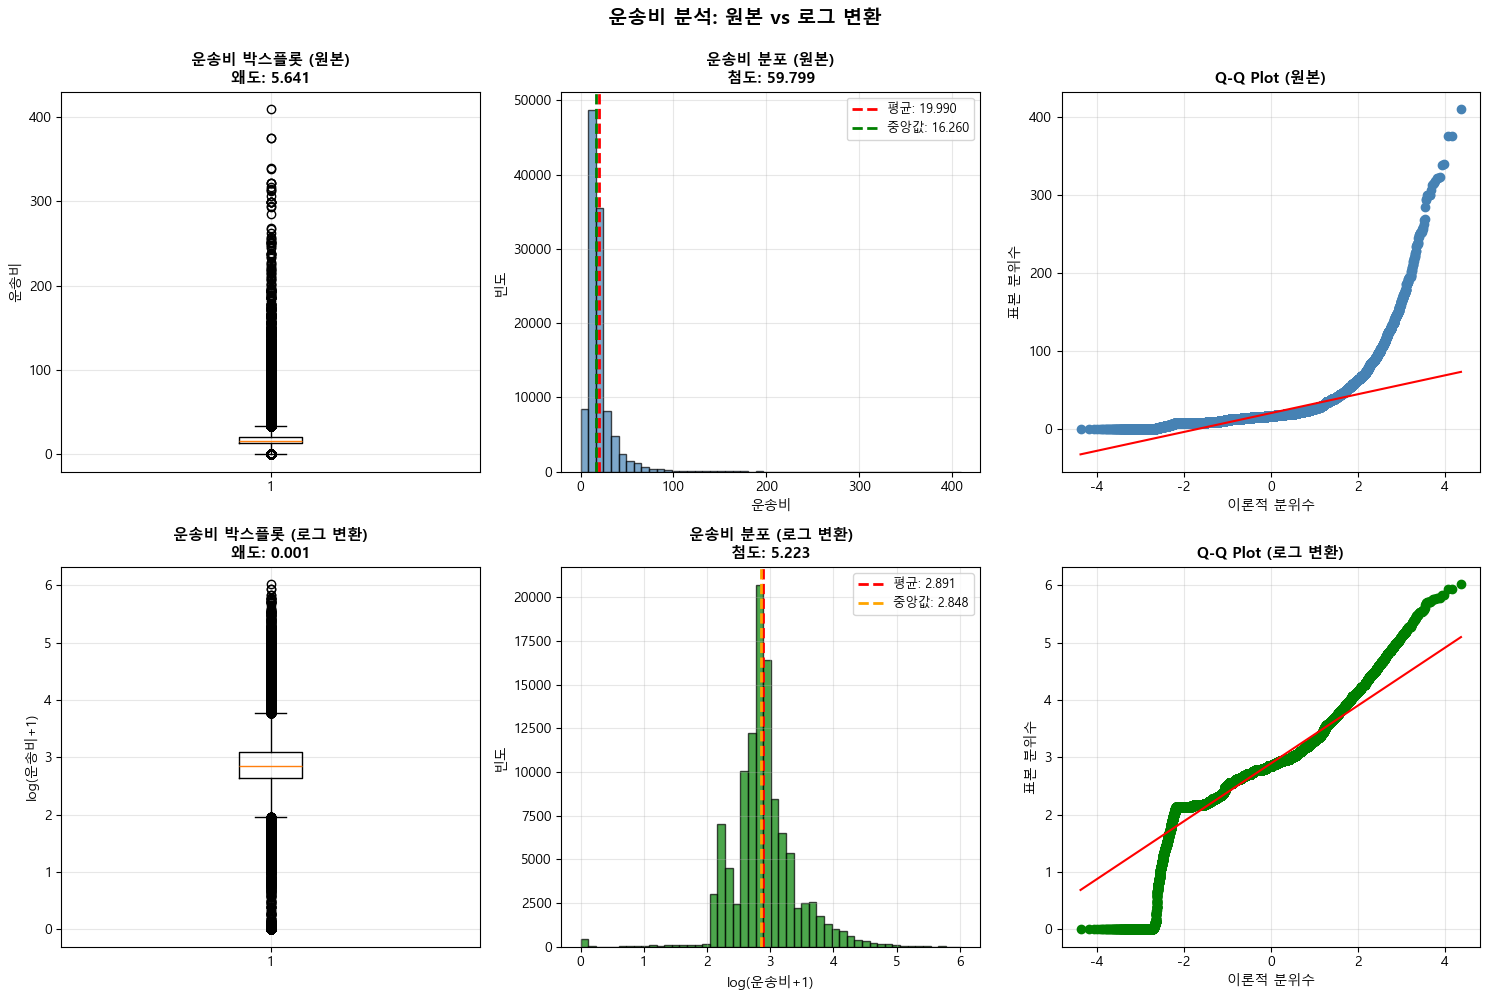

In [36]:
# 시각화 - 원본 vs 로그 변환 비교
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 로그 변환
price_log = np.log1p(df_order_items['freight_value'])  # log(price + 1)

# 로그 변환 후 왜도와 첨도
price_log_skew = skew(price_log)
price_log_kurt = kurtosis(price_log)

# ============================================================================
# 첫 번째 행: 원본 데이터
# ============================================================================

# 1. 박스플롯 (원본)
axes[0, 0].boxplot(df_order_items['freight_value'])
axes[0, 0].set_title(f'운송비 박스플롯 (원본)\n왜도: {price_skew:.3f}', 
                     fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('운송비')
axes[0, 0].grid(True, alpha=0.3)

# 2. 히스토그램 (원본)
axes[0, 1].hist(df_order_items['freight_value'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 1].axvline(df_order_items['freight_value'].mean(), color='red', linestyle='--', 
                    linewidth=2, label=f'평균: {df_order_items["freight_value"].mean():.3f}')
axes[0, 1].axvline(df_order_items['freight_value'].median(), color='green', linestyle='--',
                    linewidth=2, label=f'중앙값: {df_order_items["freight_value"].median():.3f}')
axes[0, 1].set_title(f'운송비 분포 (원본)\n첨도: {price_kurt:.3f}', 
                     fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('운송비')
axes[0, 1].set_ylabel('빈도')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q plot (원본)
stats.probplot(df_order_items['freight_value'], dist="norm", plot=axes[0, 2])
axes[0, 2].get_lines()[0].set_markerfacecolor('steelblue')  # 점 색상 통일
axes[0, 2].get_lines()[0].set_markeredgecolor('steelblue')
axes[0, 2].set_title('Q-Q Plot (원본)', fontsize=11, fontweight='bold')
axes[0, 2].set_xlabel('이론적 분위수')
axes[0, 2].set_ylabel('표본 분위수')
axes[0, 2].grid(True, alpha=0.3)

# ============================================================================
# 두 번째 행: 로그 변환 데이터
# ============================================================================

# 1. 박스플롯 (로그)
axes[1, 0].boxplot(price_log)
axes[1, 0].set_title(f'운송비 박스플롯 (로그 변환)\n왜도: {price_log_skew:.3f}', 
                     fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('log(운송비+1)')
axes[1, 0].grid(True, alpha=0.3)

# 2. 히스토그램 (로그)
axes[1, 1].hist(price_log, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1, 1].axvline(price_log.mean(), color='red', linestyle='--',
                    linewidth=2, label=f'평균: {price_log.mean():.3f}')
axes[1, 1].axvline(price_log.median(), color='orange', linestyle='--',
                    linewidth=2, label=f'중앙값: {price_log.median():.3f}')
axes[1, 1].set_title(f'운송비 분포 (로그 변환)\n첨도: {price_log_kurt:.3f}', 
                     fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('log(운송비+1)')
axes[1, 1].set_ylabel('빈도')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

# 3. Q-Q plot (로그)
stats.probplot(price_log, dist="norm", plot=axes[1, 2])
axes[1, 2].get_lines()[0].set_markerfacecolor('green')  # 점 색상 통일
axes[1, 2].get_lines()[0].set_markeredgecolor('green')
axes[1, 2].set_title('Q-Q Plot (로그 변환)', fontsize=11, fontweight='bold')
axes[1, 2].set_xlabel('이론적 분위수')
axes[1, 2].set_ylabel('표본 분위수')
axes[1, 2].grid(True, alpha=0.3)

# 전체 제목
fig.suptitle('운송비 분석: 원본 vs 로그 변환', fontsize=14, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()


In [37]:
# 5.seller_zip_code_prefix 범위 확인
df_sellers['seller_zip_code_prefix'].value_counts().sort_index()

seller_zip_code_prefix
1001     1
1021     2
1022     1
1023     2
1026     8
        ..
99300    1
99500    3
99670    1
99700    1
99730    1
Name: count, Length: 2246, dtype: int64

- 5자리로 정상임!

In [38]:
# 6.seller_state 개수 확인
df_sellers['seller_state'].nunique()

23

In [39]:
df_sellers['seller_state'].value_counts()

seller_state
SP    1849
PR     349
MG     244
SC     190
RJ     171
RS     129
GO      40
DF      30
ES      23
BA      19
CE      13
PE       9
PB       6
RN       5
MS       5
MT       4
RO       2
SE       2
AC       1
PI       1
MA       1
AM       1
PA       1
Name: count, dtype: int64

- 23개로 주 개수도 도메인 지식 상 정상임.

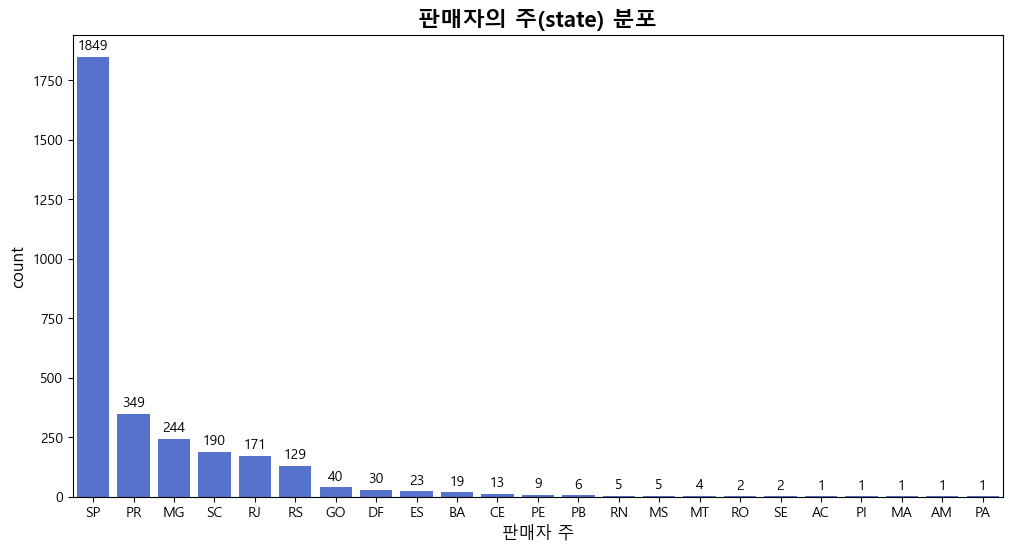

In [40]:
# 판매자의 주 분포 확인
plt.figure(figsize=(12,6))
ax = sns.countplot(
    data=df_sellers, 
    x='seller_state', 
    color='royalblue',
    order=df_sellers['seller_state'].value_counts().index)
plt.title('판매자의 주(state) 분포', fontsize=16, fontweight='bold')
plt.xlabel('판매자 주', fontsize=12)
plt.ylabel('count', fontsize=12)

ax.bar_label(ax.containers[0], fontsize=10, padding=3)

plt.show()

In [41]:
seller_state_ratio = df_sellers['seller_state'].value_counts(normalize=True) * 100
print(f"{seller_state_ratio.round(2)}")

seller_state
SP    59.74
PR    11.28
MG     7.88
SC     6.14
RJ     5.53
RS     4.17
GO     1.29
DF     0.97
ES     0.74
BA     0.61
CE     0.42
PE     0.29
PB     0.19
RN     0.16
MS     0.16
MT     0.13
RO     0.06
SE     0.06
AC     0.03
PI     0.03
MA     0.03
AM     0.03
PA     0.03
Name: proportion, dtype: float64


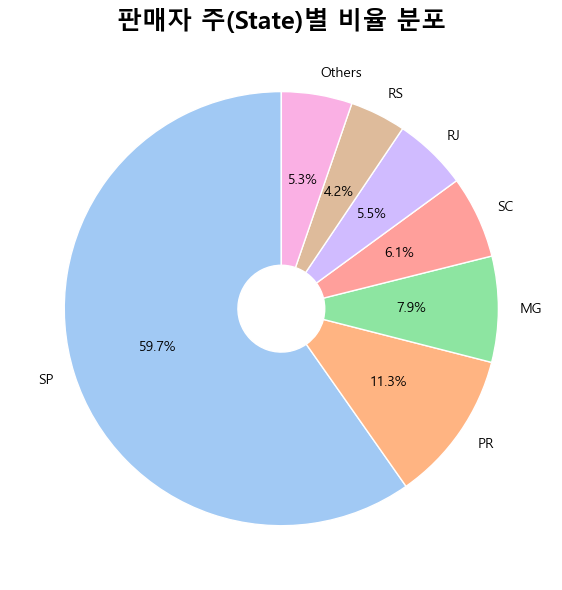

In [42]:
# 판매자의 주 비율 확인
seller_state_counts = df_sellers['seller_state'].value_counts()
seller_state_ratio = seller_state_counts / seller_state_counts.sum() * 100

#2% 미만인 주들을 기타로 묶음
main_seller_states = seller_state_ratio[seller_state_ratio >= 2.0]
other_seller_states = seller_state_ratio[seller_state_ratio < 2.0].sum()

main_seller_states['Others'] = other_seller_states

main_seller_states

plt.figure(figsize=(8,6))
plt.pie(
    main_seller_states,
    labels=main_seller_states.index,
    autopct='%.1f%%',
    startangle=90,
    colors=sns.color_palette('pastel'),
    wedgeprops={'width': 0.8, 'edgecolor': 'white'}
)

plt.title('판매자 주(State)별 비율 분포', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [43]:
df_customers['customer_state'].value_counts()

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
PE     1652
CE     1336
PA      975
MT      907
MA      747
MS      715
PB      536
PI      495
RN      485
AL      413
SE      350
TO      280
RO      253
AM      148
AC       81
AP       68
RR       46
Name: count, dtype: int64

In [44]:
# df_customers['customer_state'].unique()

In [45]:
# customer_state_ratio = df_customers['customer_state'].value_counts(normalize=True) * 100
# print(f"{customer_state_ratio.round(2)}")

In [46]:
# # 구매자의 주 비율 확인
# customer_state_counts = df_customers['customer_state'].value_counts()
# customer_state_ratio = customer_state_counts / customer_state_counts.sum() * 100

# # 2% 미만인 주들을 기타로 묶음
# main_customer_states = customer_state_ratio[customer_state_ratio >= 2.0]
# other_customer_states = customer_state_ratio[customer_state_ratio < 2.0].sum()

# main_customer_states['Others'] = other_customer_states

# plt.figure(figsize=(8,6))
# plt.pie(
#     main_customer_states,
#     labels=main_customer_states.index,
#     autopct='%.1f%%',
#     startangle=90,
#     colors=sns.color_palette('pastel'),
#     wedgeprops={'width': 0.8, 'edgecolor': 'white'}
# )

# plt.title('구매자 주(State)별 비율 분포', fontsize=18, fontweight='bold')
# plt.tight_layout()
# plt.show()

In [47]:
df = pd.merge(df_orders, df_customers, on='customer_id', how='left')
df = pd.merge(df, df_order_items, on='order_id', how='left')
df = pd.merge(df, df_order_payments, on='order_id', how='left')
df = pd.merge(df, df_order_reviews, on='order_id', how='left')
df = pd.merge(df, df_products, on='product_id', how='left')
df = pd.merge(df, df_sellers, on='seller_id', how='left')

In [49]:
df_sellers.head()
df_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


## 